In [1]:
using DifferentialEquations
using Plots

In [18]:
println("\nМоделирование завершено успешно!")


Моделирование завершено успешно!


In [60]:
### 1. Случай 1: Моделирование и построение графиков
#Определяем параметры обеих фирм, критическую стоимость продукта, производственные циклы, себестоимость и емкость рынка.

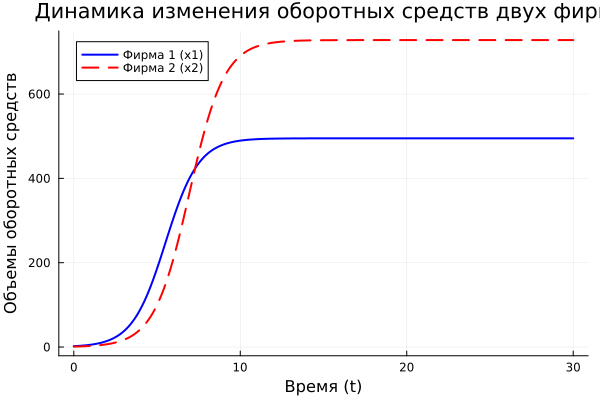

In [56]:
# Параметры задачи (на основе примера из методички)
p_cr = 20.0  # критическая стоимость продукта
tau1 = 10.0  # длительность производственного цикла фирмы 1
p1 = 9.0     # себестоимость продукта у фирмы 1
tau2 = 16.0  # длительность производственного цикла фирмы 2
p2 = 7.0     # себестоимость продукта у фирмы 2
V = 10.0     # число потребителей производимого продукта
q = 1.0      # максимальная потребность одного человека в продукте в единицу времени

# Коэффициенты модели
al1 = p_cr / (tau1 * tau1 * p1 * p1 * V * q)
al2 = p_cr / (tau2 * tau2 * p2 * p2 * V * q)
b = p_cr / (tau1 * tau1 * tau2 * tau2 * p1 * p1 * p2 * p2 * V * q)
c1 = (p_cr - p1) / (tau1 * p1)
c2 = (p_cr - p2) / (tau2 * p2)

# Дифференциальная система уравнений для двух конкурирующих фирм
function competing_firms!(dx, x, p, t)
    x1, x2 = x
    # Görseldeki formüle birebir uygun kod:
    dx[1] = (c1 / c1) * x1 - (al1 / c1) * x1 * x1 - (b / c1) * x1 * x2
    dx[2] = (c2 / c1) * x2 - (al2 / c1) * x2 * x2 - (b / c1) * x1 * x2
end

# Начальные значения и временной интервал
tspan = (0.0, 30.0)
x0 = [2.0, 1.0]  # Начальный объем оборотных средств x1 ve x2

prob = ODEProblem(competing_firms!, x0, tspan)
sol = solve(prob, Tsit5(), saveat=0.1)

# Grafik oluşturma
plot(sol.t, [u[1] for u in sol.u], label="Фирма 1 (x1)", color=:blue, linewidth=2)
plot!(sol.t, [u[2] for u in sol.u], label="Фирма 2 (x2)", color=:red, linewidth=2, linestyle=:dash)
xlabel!("Время (t)")
ylabel!("Объемы оборотных средств")
title!("Динамика изменения оборотных средств двух фирм")

In [58]:
### 3. Нахождение стационарного состояния системы для первого случая
#Стационарное состояние системы достигается тогда, когда производные равны нулю ($dx_1/dt = 0$ ve $dx_2/dt = 0$).

In [59]:
# Stasyoner noktaların cebirsel denklemlerden çözümü (İç denge durumu x1 > 0 ve x2 > 0)
# c1 - al1*x1 - b*x2 = 0
# c2 - al2*x2 - b*x1 = 0

# Matris çözümü (A * X = B)
A = [al1 b; b al2]
B = [c1, c2]
steady_state = A \ B

println("--- Стационарное состояние системы ---")
println("Стационарный объем средств фирмы 1 (x1*): ", steady_state[1])
println("Стационарный объем средств фирмы 2 (x2*): ", steady_state[2])

--- Стационарное состояние системы ---
Стационарный объем средств фирмы 1 (x1*): 494.9419691568835
Стационарный объем средств фирмы 2 (x2*): 727.9388960531907
